# DS 3000 HW 2

Due: Monday June 2 @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file to Gradescope (no need to do it through GitHub).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the `ipynb` file to gradescope.

### Tips for success
- Start early
- Make use of Slack
- Remember to use cells, headings and markdown to make the notebook easy to read (if I can't find the answer to a problem, you will receive no points for it)
- Collaborate: bounce ideas off of each other, if you are having trouble you can ask your classmates or Dr. Gerber for help with specific issues, however...
- [(See)](http://www.northeastern.edu/osccr/academic-integrity), i.e. you are welcome to **talk about/discuss** (*not* show or allow each other to copy your answers to) the problems.

### Prize for 3.1

Whoever builds the best model (evaluated in terms of both cross validated $R^2$ and meeting assumptions) will receive a prize of a Belgian soccer flag and a Belgian waffle.

In [4]:
# functions for you
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Part 1: Writing Your Own Linear Regression Functions

In this part, you will write your own linear regression functions that can (and will) be used for both Part 2 and Part 3. You must make sure that your functions pass the assert statements in each sub-part.

## Part 1.1: Line of Best Fit Function (20 points)

Write the function `line_of_best_fit`, including well written docstring, which takes as arguments `X` (an array, either 1-d or 2-d which includes all the predictor values, not including bias term) and `y` (a 1-d array which includes all corresponding response values to `X`) and returns the vector containing the coefficients for the line of best fit, including an intercept term. I have written the `add_bias_column` function below which you will want to use within your `line_of_best_fit` function. **Make sure the assert statement written in the final code cell of this sub-part passes.**

In [5]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [6]:
def line_of_best_fit(X, y):
    '''
    Finds the coefficient vector for projecting a value onto X
    X: a 1d or 2d matrix with the predictor values 
    y: a 1d all the corresponding X values
    returns the coefficient vector
    '''
    Xnew = add_bias_column(X)
    Xtx = np.dot(Xnew.T,Xnew)
    inv = np.linalg.inv(Xtx)
    Xty = np.dot(Xnew.T, y)
    p = np.dot(inv, Xty)
    
   
    return p

In [7]:
X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])
assert (np.isclose(line_of_best_fit(X, y), np.array([3., 1.]))).all()



## Part 1.2: Prediction and Assessment Function (20 points)

Write the function `linreg_predict`, including well written docstring, which takes as arguments:

- `Xnew` (an array, either 1-d or 2-d which includes all the $p$ predictor features, not including bias term)
- `ynew` (a 1-d array which includes all corresponding response values to `Xnew`)
- `b` (a 1-d array of length $p+1$ which contains the coefficients from the `line_of_best_fit` function)

The function should return a dictionary containing four key-value pairs:

- `'ypreds'` (the predicted values from applying `m` to `Xnew`)
- `'resids'` (the residuals, the differences between `ynew` and `ypreds`)
- `'mse'` (the mean squared error)
- `'r2'` (the coefficient of determination ($R^2$) representing the proportion of variability in `ynew` explained by the line of best fit
  - You **do not** have to calculate this manually; you may use the `r2_score` function from `sklearn` (imported for you below)

**Note** you will want to use the `add_bias_column` again within your function before calculating all the outputs in your dictionary. **Also, make sure the assert statement written in the final code cell of this sub-part passes.**

In [8]:
from sklearn.metrics import r2_score

In [12]:
def linreg_predict(Xnew, ynew, b):
    '''
    Predicts responses for new input data using linear regression coefficients,
    and evaluates prediction performance.
    Xnew: a matrix with X values to predict
    ynew: the correct correspondng values for the Xnew Matrix
    b: the coefficient vector for matrix Xnew

    returns a dictionary with details regarding the models predictions and accuracy.
    '''
    linear_reg = {}
    Xnew = add_bias_column(Xnew)
    ypreds = Xnew @ b 
    resids = ynew - ypreds
    mse = np.mean((ynew - ypreds)**2)
    r2 = r2_score(ynew, ypreds)
    linear_reg['ypreds'] = ypreds
    linear_reg['resids'] = resids
    linear_reg['mse'] = mse
    linear_reg['r2'] = r2
    return linear_reg
    
    
    

In [13]:
def compare_dicts(dict1, dict2):
    """ compares two dictionaries

    Args:
        dict1 (dict): the first dictionary
        dict2 (dict): the second dictionary

    Returns:
        (bool) False if the dictionaries are not close to being the same, True if they are
    """
    
    if dict1.keys() != dict2.keys():
        return False

    for key in dict1:
        if not np.isclose(dict1[key], dict2[key]).all():
            return False

    return True

expected_out = {'ypreds': np.array([3., 5., 4., 3., 7.]),
                'resids': np.array([0., 3., -2., 0., -1.]),
                'mse': 2.8,
                'r2': 0.4444444444444444}

X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])

b = line_of_best_fit(X, y)

out = linreg_predict(X, y, b)
out
assert compare_dicts(expected_out, out)

# Part 2: Belgium Energy Simple Linear Regression

For this problem you will use the `GDP_Energy_WBdat.csv` file on Canvas (the same one you used on Quiz 1). The data set contains the GDP (\$ per capita), Total Fossil Fuel Energy Consumption (as a \% of total energy), CO$^2$ emissions (kt), and Urban Population of the current 27 European Union member states from 1990 to 2015 (with a few years/countries missing). It was accessed via the World Bank API (which is also linked on Canvas).

## Part 2.1: Reading, Curating, and Exploring Data (10 points)

Read in the data set and create the `CO2_Upop` column like you did on the Quiz (i.e. create a column which scales CO$^2$ emissions by Urban Population). Print the head to show it worked.

Subset the data to only include observations from Belgium, then standardize all the numeric features (do this differently than I did in class, making sure to keep the first two columns, `country` and `date`). Print the head to show it worked.

Then, **YOU DECIDE** which two features you want to build a simple linear regression model for by doing some data exploration and visualization. In this part 2, you will choose one $x$ feature to predict one $y$ feature. You must provide a markdown cell with your reasoning which references (a) why you think there may be a useful causal relationship between the two features and (b) some numerical summary statistics and plots (i.e. perhaps correlation and a scatterplot).

In [15]:
gdp_df = pd.read_csv("GDP_Energy_WBdat.csv")
ratios = []
for row in gdp_df.iterrows():
    urban_pop = row[1]['Urban_pop']
    CO2_emit = row[1]['CO2_emit']
    ratios.append(CO2_emit/urban_pop)
gdp_df['CO2_Upop'] = pd.Series(ratios)
gdp_df.head(10)
gdp_df

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
0,Austria,1990,21680.989623,79.132345,58275.7,4833974.0,0.012055
1,Austria,1991,22410.911767,79.127007,62423.2,4861464.0,0.012840
2,Austria,1992,24880.164118,77.237211,57668.0,4893935.0,0.011784
3,Austria,1993,24081.527793,77.011142,57804.0,4912877.0,0.011766
4,Austria,1994,25646.700659,77.585708,58288.2,4910076.0,0.011871
...,...,...,...,...,...,...,...
660,Sweden,2011,60755.759551,34.214187,44452.0,8059895.0,0.005515
661,Sweden,2012,58037.821319,30.999156,41996.6,8150488.0,0.005153
662,Sweden,2013,61126.943196,30.016016,40388.1,8250182.0,0.004895
663,Sweden,2014,60020.360458,29.774747,38993.0,8362604.0,0.004663


In [16]:
num_cols = [col for col in gdp_df.columns if (gdp_df[col].dtype == float) and (not col.endswith('_standardized'))]
for col in num_cols:
    mean = gdp_df[col].mean()
    std = gdp_df[col].std()
    gdp_df[col + '_standardized'] = (gdp_df[col] - mean) / std
belgium = gdp_df[gdp_df['country'] == "Belgium"]
belgium

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop,GDP_standardized,Fossil_Fuels_standardized,CO2_emit_standardized,Urban_pop_standardized,CO2_Upop_standardized
26,Belgium,1990,20600.375279,75.815870,109312.6,9606261.0,0.011379,-0.164288,-0.028954,-0.109215,-0.151278,-0.031571
27,Belgium,1991,21041.660652,76.397007,113960.1,9650427.0,0.011809,-0.141191,0.003092,-0.083576,-0.148479,0.059813
28,Belgium,1992,23372.619171,75.932201,112329.3,9697796.0,0.011583,-0.019188,-0.022539,-0.092573,-0.145476,0.011761
29,Belgium,1993,22283.936021,75.935015,110108.3,9743821.0,0.011300,-0.076170,-0.022384,-0.104826,-0.142559,-0.048377
30,Belgium,1994,24208.554793,77.649375,114901.4,9781788.0,0.011746,0.024565,0.072151,-0.078383,-0.140153,0.046546
31,Belgium,1995,28413.826439,77.405698,114568.7,9810102.0,0.011679,0.244670,0.058714,-0.080219,-0.138358,0.032117
32,Belgium,1996,27489.555177,77.644484,119448.4,9836805.0,0.012143,0.196293,0.071881,-0.053299,-0.136666,0.130918
33,Belgium,1997,24820.938050,75.898319,116634.7,9868070.0,0.011819,0.056617,-0.024407,-0.068821,-0.134684,0.062066
34,Belgium,1998,25338.443293,77.048527,119412.8,9896510.0,0.012066,0.083704,0.039018,-0.053495,-0.132882,0.114566
35,Belgium,1999,25252.801907,75.790143,115514.5,9926274.0,0.011637,0.079221,-0.030373,-0.075001,-0.130995,0.023309


## Part 2.2: Cross Validate, Predict, MSE, and $R^2$ (10 points)

Create arrays `X` and `y` which contain your chosen $x$ and $y$ features (these will both be 1-d arrays for this problem).

Use the `train_test_split` function (with the **the `random_state=42` option**) which I've imported for you below to create a single-fold (70-30 split) cross validation set (i.e. `Xtrain`, `Xtest`, `ytrain`, `ytest`) using the data you cleaned in Part 2.1. In other words, for example, the `Xtrain` set should contain a random subset of about 70\% of the `X` values.

Using your functions from Part 1, apply the `line_of_best_fit` function to training data and use the `linreg_predict` function with the test data (and the output from the first function). Print out the resulting cross validated $MSE$ and $R^2$ values and **then**, in a markdown cell, interpret $R^2$ and discuss (based on that alone) if you think it is reasonable to predict your $y$ value with your $x$ value.

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X  = np.array(belgium['GDP_standardized'])
y = np.array(belgium['Fossil_Fuels_standardized'])
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
b = line_of_best_fit(Xtrain,ytrain)
linreg_predict(Xtest,ytest,b)

{'ypreds': array([-0.0019468 , -0.14150932,  0.04752379, -0.23609477,  0.02231173,
        -0.00105261, -0.05745962,  0.04291629]),
 'resids': array([ 0.04096507,  0.00925312, -0.07647771,  0.03270396, -0.0616092 ,
        -0.02931997, -0.00364389, -0.03982468]),
 'mse': 0.0018670980466008358,
 'r2': 0.642225496366919}

# My analysis of the $R^2$ value

The $R^2$ value of our regression was .6422 which means that around 64% of the variance in Fossil Fuels can be explained by our model. This is a decently strong and acceptable $R^2$ value; however it is by no means very accurate or strong. For a rough prediction, our model is strong but would not be recommended if there were high stakes as there is still 36% of variance that cannot be explained. 

## Part 2.3: Plot and Interpret the Full Line (10 points)

Now, fit the regression model to the full data set, then use the `show_fit()` function below to plot it and recover the final best fit line for the model. **Note** that your `line_of_best_fit` function is the only one you need here, and that you will have to remember which value in the output vector is the slope and which is the intercept.

**In a markdown cell**, interpret both the slope and intercept in the context of the problem, explaining what they mean (as best as you can). **Recall** you standardized both the features earlier, which will impact your interpretation; think critically about that.

[ 0.00048627 -0.18073239]


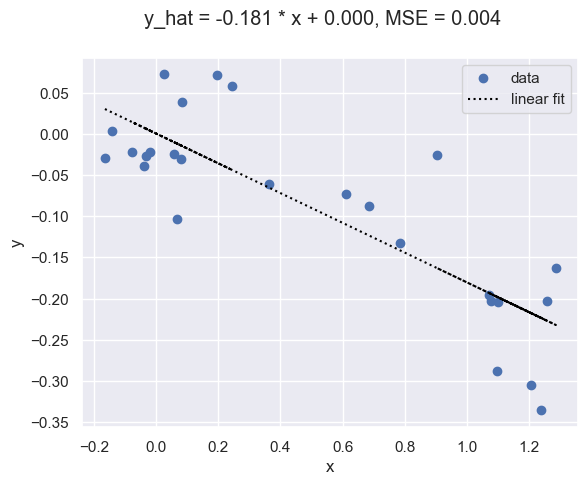

In [21]:
sns.set()

def get_mse(y_true, y_pred):
    """ gets the MSE

    Args:
        y_true (array): the true y values
        y_pred (array): the predicted y values

    Returns:
        the mean squared error

    """
    
    return np.mean((y_true - y_pred) ** 2)

def show_fit(X, y, slope, intercept):
    """ plots a simple linear regression line through x y points and prints the slope, intercept, and MSE

    Args:
        X (array): the design matrix
        y (array): the response variable
        slope (float): the slope
        intercept (float): the intercept

    Returns:
        A plot (I'm getting lazy with these...)
    """
    
    plt.figure()
    
    # in case this wasn't done before, transform the input data into numpy arrays and flatten them
    x = np.array(X).ravel()
    y = np.array(y).ravel()
    
    # plot the actual data
    plt.scatter(x, y, label='data')
    
    # compute linear predictions 
    # x is a numpy array so each element gets multiplied by slope and intercept is added
    y_pred = slope * x + intercept
    
    # plot the linear fit
    plt.plot(x, y_pred, color='black',
             ls=':',
             label='linear fit')
    
    plt.legend()
    
    plt.xlabel('x')
    plt.ylabel('y')
    
    # print the mean squared error
    y_pred = slope * x + intercept
    mse = get_mse(y_true=y, y_pred=y_pred)
    plt.suptitle(f'y_hat = {slope:.3f} * x + {intercept:.3f}, MSE = {mse:.3f}')

b_full = line_of_best_fit(X, y)
print(b_full)
show_fit(X,y, b_full[1],b_full[0])



# Analysis of the Slope and Intercepts in this regression
Once you standardize the GDP and Fossil Fuel Emissions in Belgium, you can see that there is a decent correlation among the two features. For each standard deviation increase in GDP, you can expect a decrease in Fossil Fuel Emissions of about .181 standard deviations on average. 

## Part 2.4: Check Assumptions and Make Recommendations (10 points)

Use two plots to check to see if the residuals meet the assumptions for performing a *simple* linear regression:
1. linearity and homoscedasticity
2. no autocorrelation

**Note** that you will want to use your `linreg_predict` function, using the **full data set** as your `Xnew` and `ynew` values, to get the residuals for the purposes of this question.

Then, **in a markdown cell**, write 3-4 sentences about whether the model meets the assumptions, what that tells you about the usefulness of the model, and recommendations for next steps (if any).

Text(0.5, 1.0, 'Residuals vs X values')

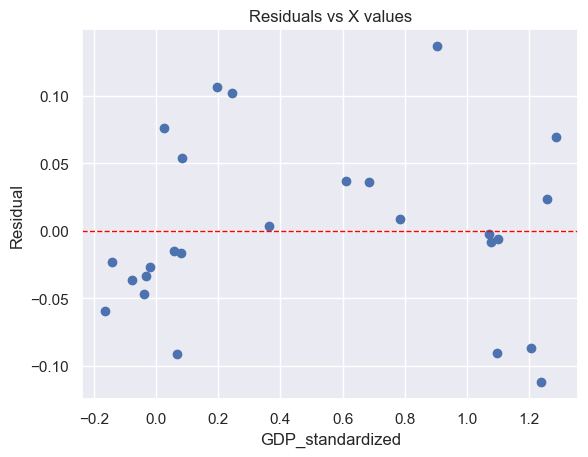

In [23]:
linreg = linreg_predict(X,y,b_full)
resids = linreg['resids']
plt.scatter(X, resids)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("GDP_standardized")
plt.ylabel("Residual")
plt.title("Residuals vs X values")


Text(0.5, 1.0, 'Residuals vs Order')

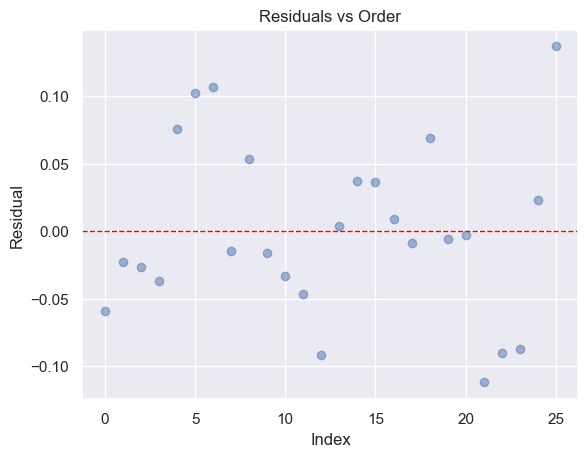

In [25]:
plt.scatter(range(len(X)), resids, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Residuals vs Order")

# Checking Assumptions 

After looking at the Residuals vs X values plot, you can see that:

The residuals are relatively evenly scattered around zero at all values of X, which implies homoscedasticity.

There is no obvious pattern in the residuals, suggesting that a linear relationship is appropriate between X and y.

After looking at the Residuals vs Order plot:

There is no clear grouping or pattern of residuals over time (or order), which implies no autocorrelation and no lurking variable related to ordering.



# Part 3: More Complex Regression 

## Part 3.1: Predicting GDP (15 points)

Suppose a Belgian policy maker comes to you now and asks you to use this data to build a model to predict `GDP` **specifically**. To build a linear regression model for GDP using **more than 1 predictor** (i.e. include at least one additional $x$ feature(s) as linear terms for your model):

1. Fit your model to a training set and the evaluate on a testing set; report the training $MSE$, $R^2$. Then, fit the full data set and interpret the intercept and slopes (you will have multiple slopes, since you will have more than 1 predictor).
2. Check the assumptions of linearity, homoscedasticity, and no autocorrelation using the residuals of the full data set.
   - **Note** To check homoscedasticity and linearity, you should plot *each* of the $x$ features you choose against the residuals.
4. Finally, decide (based on what you've done) if the model you built seems like a useful model that you would be willing to show to the Belgian policy maker.

In [28]:
y  = np.array(belgium['GDP_standardized'])
X = np.array(belgium[['Fossil_Fuels_standardized','Urban_pop_standardized']])

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
b = line_of_best_fit(Xtrain,ytrain)
linreg = linreg_predict(Xtest,ytest,b)
b_full = line_of_best_fit(X, y)
#show_fit(X,y, b_full[1],b_full[0])
linreg_full = linreg_predict(X,y, b_full)
b_full

array([ 1.84820315, -1.31103391, 12.88034706])

# The Slopes and Intercept analysis
The intercept of 1.848 means that when both standardized features are at their mean values (i.e., 0 after standardization), the standardized GDP is 1.848 standard deviations above the mean GDP. Additionally, 1 standard deviation increase in Fossil_Fuels correlates with a GDP decrease of 1.31 standard deviations while a 1 standard deviation increase in Urban Population crrelates with a GDP increase of 13 standard deviations. 

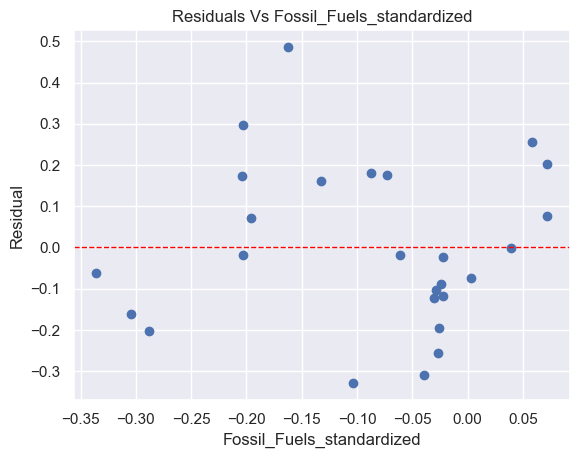

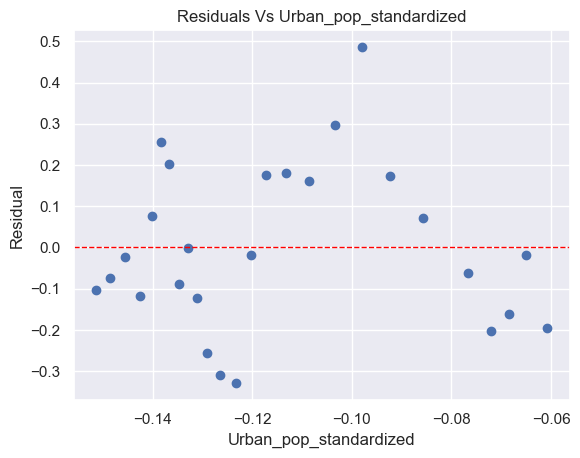

In [31]:
resids = linreg_full['resids']
features = ['Fossil_Fuels_standardized','Urban_pop_standardized']

for i in range(X.shape[1]):
    plt.figure()
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
    plt.scatter(X[:,i], resids)
    plt.title(f"Residuals Vs {features[i]}")
    plt.xlabel(features[i])
    plt.ylabel("Residual")
    







Text(0.5, 1.0, 'Residual Vs order')

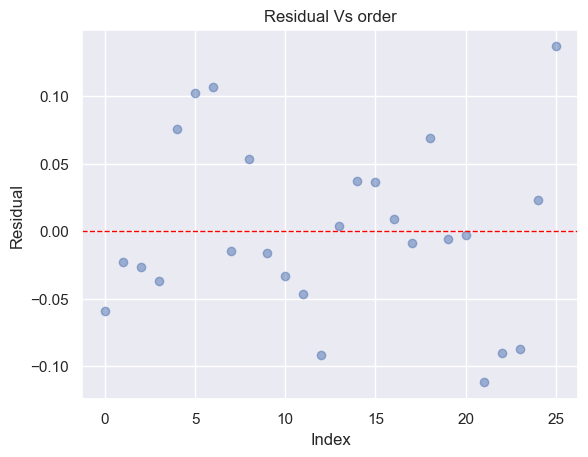

In [26]:
plt.scatter(range(len(X)),resids, alpha = .5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.ylabel('Residual')
plt.xlabel('Index')
plt.title('Residual Vs order')

# Checking Assumptions
### After checking the first 2 plots which show features against their residuals, we can see:

- For both plots, there seems to be no issues with homoscedasticity as the points are equally spread around 0.
- For both plots, there seems to be no pattern in the residuals implying that the linear model is appropriate

### The Final Plot tells us that:

- There is no issues with grouping or autocorrelation as there seems to be no pattern with points of similar characteristics bunched up

## Part 3.2: The Last Assumption (5 points)

The Belgian policy maker, when assigning you the previous task, had suggested to use all the other features to help predict `GDP`. Whether you did or not, do you think there may be reason to believe such a model would be at risk of multicollinearity issues? Explain (to the policy maker) why that may or may not be in a few sentences.

# 3.2 
Features such as **Carbon Emissions and Urban Population** will definitely suffer from multicolinearity. The Feature Carbon/UPop is mathematically related to these 2 features and will consequientally be very dependent on them. Fossil Fuel usage and Carbon Dioxide emissions may be strongly correlated, because fossil fuel consumption is typically the primary driver of CO₂ emissions.

## Part 3.3: Extra Credit (5 points)

We want to compare a simple linear model (if you haven't already) predicting GDP with Fossil Fuels, and a **quadratic** model with Fossil Fuels (i.e. your $X$ design matrix will include a column with Fossil Fuels ($x$ values) and Fossil Fuels squared ($x^2$)). 

1. Fit both models with the full data set and compare their $MSE$ and $R^2$ values; which model (based on these values) would you choose?
2. Check the assumptions of homoscedasticity and no autocorrelation using residual plots for both models (since there is only one $x$ feature for both models, you only need two plots for each).
3. Make a declaration about which model is "better", and if you think the "better" model is actually good, or may need more work.